**EDA Fase 1: Diagnóstico de RECH1 (Características de los Miembros del Hogar)**

Objetivo: Extraer las variables críticas que pide la Ficha Técnica del INEI para el cruce de desnutrición crónica (2007-2024):
- `HVIDX`: Índice del miembro del hogar (llave de cruce con `HC0` de Antropometría)
- `HV103`: Si el niño durmió en casa anoche
- `HV104`: Sexo

In [1]:
import pandas as pd
import gc
from mnp.ingestion.loader import load_endes

# 1. Carga de historial desde 2007
history = load_endes(year=range(2007, 2025), module='household', record='rech1', meta=True)

frames = []
diccionario = {}

# Extraemos y liberamos memoria progresivamente usando pop()
for yr in sorted(list(history.keys())):
    df_yr, meta_yr = history.pop(yr)
    frames.append(df_yr.assign(year=yr))
    diccionario.update(meta_yr.column_names_to_labels)

df_rech1 = pd.concat(frames, ignore_index=True)
del frames
gc.collect() # Forzar limpieza de memoria

print(f"Registros RECH1 totales: {len(df_rech1)}")
print(f"Columnas RECH1 totales: {df_rech1.shape[1]}")

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k
2026-05-28 02:04:52.790 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /workspace


2026-05-28 02:04:52.999 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH1.SAV desde Modulo64 [Alias: rech1]
2026-05-28 02:04:53.821 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH1.SAV desde Modulo64 [Alias: rech1]
2026-05-28 02:04:54.968 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH1.SAV desde Modulo64 [Alias: rech1]
2026-05-28 02:04:55.741 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH1.SAV desde Modulo64 [Alias: rech1]
2026-05-28 02:04:56.481 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH1.sav desde Modulo64 [Alias: rech1]
2026-05-28 02:04:57.172 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH1.sav desde Modulo64 [Alias: rech1]
2026-05-28 02:04:57.897 | INFO     | mnp.ingestion.loader:load_endes:379 - ✓ Cargando registro: RECH1.SAV desde Modulo64 [Alias: rech1]
2026-05-28 02:04:58.849 | INFO     | mnp.ingesti

In [2]:
# 2. Verificando la presencia de las variables críticas (HV103 y HVIDX) y Porcentaje de nulos
nulos = df_rech1.isna().mean().sort_values(ascending=False) * 100

criticas = ['HHID', 'HVIDX', 'HV103', 'HV104']
print("Estado de variables críticas:")
for col in criticas:
    if col in df_rech1.columns:
        pct_nulo = nulos.get(col, 0.0)
        print(f"{col:6s} | Nulos: {pct_nulo:.2f}% | {diccionario.get(col, '')}")
    else:
        print(f"ALERTA: {col} no existe en el dataset")

print("\nVariables con > 90% de nulos:")
for col, pct in nulos[nulos > 90].items():
    etiqueta = diccionario.get(col, 'Sin etiqueta')
    print(f"{col:7s} | {pct:5.1f}% | {etiqueta}")

print("\nResto de variables:")
for col, pct in nulos[nulos <= 90].items():
    etiqueta = diccionario.get(col, 'Sin etiqueta')
    print(f"{col:7s} | {pct:5.1f}% | {etiqueta}")

Estado de variables críticas:
HHID   | Nulos: 0.00% | Identificación Cuestionario del Hogar
HVIDX  | Nulos: 0.00% | Número de orden
HV103  | Nulos: 0.00% | ¿Durmió aquí anoche?
HV104  | Nulos: 0.00% | Sexo

Variables con > 90% de nulos:
HV118   | 100.0% | Elegibilidad para entrevista de hombres
HV138   | 100.0% | Member has a pair of shoes
HV139   | 100.0% | Member has 2+ sets of clothes
HV135   | 100.0% | Has brothers/sisters under 18 of the same father and mother
HV136   | 100.0% | Brothers/sisters under 18 that don't live in household
HV137   | 100.0% | Member has a blanket
HV134   | 100.0% | Both parents alive
HV131   | 100.0% | Mother has been very sick for 3+ months last year
HV132   | 100.0% | Father has been very sick for 3+ months last year
HV133   | 100.0% | Mother/father dead or been very sick for 3+ months
HV130   | 100.0% | Member has been very sick for 3+ months last year
QH13A6D | 100.0% | Otra Limitacion permanente para actividad diarias
QH13A6C | 100.0% | Otra Limitaci

**Decisiones de Pre-Filtro (Ruido y Redundancia)**

Tras revisar la distribución de nulos y la utilidad de las variables para la Ficha Técnica de Desnutrición Crónica, procedemos a descartar:
1. **Ruido masivo:** Variables con más del 90% de nulos.
2. **Ruido temático:** Variables de educación (`HV12X`, `HV10X` educativos), limitaciones físicas (`QH13A...`), estado civil y supervivencia de padres biológicos, que no aplican para el cruce de antropometría del menor de 5 años.

Nos quedamos estrictamente con el bloque demográfico base (`HVIDX`, `HV103`, `HV104`, `HV105`, `HV101`, `HV102`, `HV120`).

In [5]:
# 3. Separar variables analíticas y filtrar ruido temático

# 1. Ruido masivo (>90% nulos)
vars_mas_90_nulos = nulos[nulos > 90].index.tolist()

# 2. Ruido temático (variables irrelevantes clasificadas por motivo)
motivos_descarte = {}

# Limitaciones físicas/permanentes
for v in ['QH13A6', 'QH13A2', 'QH13A4', 'QH13A1', 'QH13A3', 'QH13A5']:
    motivos_descarte[v] = 'Limitaciones físicas (No relevante para estado nutricional del menor)'

# Educación y asistencia escolar
for v in ['HV123', 'HV127', 'HV129', 'HV126', 'HV125', 'HV128', 'HV122', 'HV124', 'HV121', 'HV110', 'HV107', 'HV106', 'HV108', 'HV109']:
    motivos_descarte[v] = 'Educación/Escolaridad (No indispensable para el menor de 5 años)'

# Padres biológicos y estado civil
for v in ['HV113', 'HV111', 'HV112', 'HV114', 'HV116', 'HV115']:
    motivos_descarte[v] = 'Supervivencia padres/Estado Civil (Redundante o indirecto)'

# Nacionalidad / elegibilidad
for v in ['QH25A', 'HV117']:
    motivos_descarte[v] = 'Nacionalidad/Elegibilidad mujer (Operativo)'

vars_ruido_tematico = list(motivos_descarte.keys())

# Unimos ambos descartes
vars_descartar = set(vars_mas_90_nulos + vars_ruido_tematico)

# Variables analíticas críticas que queremos asegurar
vars_clave = ['HHID', 'HVIDX', 'HV103', 'HV104', 'HV105', 'HV101', 'HV102', 'HV120', 'year']

# Columnas finales
columnas_validas = [col for col in df_rech1.columns if (col not in vars_descartar) or (col in vars_clave)]

# Aplicamos filtro
df_analitico = df_rech1[columnas_validas]

print("--- REPORTE DE VARIABLES DESCARTADAS POR RUIDO TEMÁTICO ---")
for col in vars_ruido_tematico:
    etiqueta = diccionario.get(col, 'Sin etiqueta ENDES')
    motivo = motivos_descarte[col]
    print(f"- {col}: {etiqueta}\n  >> Motivo: {motivo}")

print(f"\n--- COLUMNAS FINALES RETENIDAS ({df_analitico.shape[1]}) ---")
for col in df_analitico.columns:
    print(f"- {col}: {diccionario.get(col, 'Sin etiqueta')}")

--- REPORTE DE VARIABLES DESCARTADAS POR RUIDO TEMÁTICO ---
- QH13A6: Limitacion permanenete para relacionarse
  >> Motivo: Limitaciones físicas (No relevante para estado nutricional del menor)
- QH13A2: Limitacion permanente para ver
  >> Motivo: Limitaciones físicas (No relevante para estado nutricional del menor)
- QH13A4: Limitacion permanente para hablar
  >> Motivo: Limitaciones físicas (No relevante para estado nutricional del menor)
- QH13A1: Limitacion permanente para moverse
  >> Motivo: Limitaciones físicas (No relevante para estado nutricional del menor)
- QH13A3: Limitacion permanente para oir
  >> Motivo: Limitaciones físicas (No relevante para estado nutricional del menor)
- QH13A5: Limitacion permanente para entender
  >> Motivo: Limitaciones físicas (No relevante para estado nutricional del menor)
- HV123: Año o grado que asiste o se matriculó
  >> Motivo: Educación/Escolaridad (No indispensable para el menor de 5 años)
- HV127: Año o grado que asistió o se matriculó
 

**Exploración Univariada y Gráficos**

Distribución de respuestas en HV103 (Durmió anoche):
HV103
1.0    2177190
0.0     114033
NaN          9
Name: count, dtype: int64


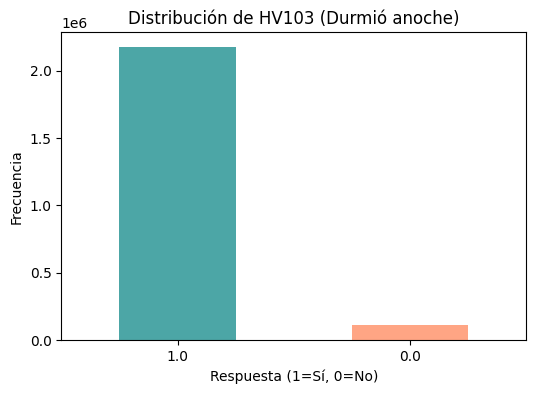

In [4]:
import matplotlib.pyplot as plt

# 4. Distribución de HV103 (Durmió anoche)
print("Distribución de respuestas en HV103 (Durmió anoche):")
print(df_analitico['HV103'].value_counts(dropna=False))

s_hv103 = pd.to_numeric(df_analitico['HV103'], errors='coerce').dropna()

plt.figure(figsize=(6,4))
s_hv103.value_counts().plot(kind='bar', color=['teal', 'coral'], alpha=0.7)
plt.title('Distribución de HV103 (Durmió anoche)')
plt.xlabel('Respuesta (1=Sí, 0=No)')
plt.ylabel('Frecuencia')
plt.xticks(ticks=[0, 1], labels=['1.0', '0.0'], rotation=0)
plt.show()

**Nota Metodológica: ¿Por qué RECH1 tiene millones de registros y RECH6 solo miles?**

Si contrastamos este notebook con el de Antropometría (`RECH6`), notaremos una diferencia abismal en el volumen de datos (2.2 millones vs ~20 mil). Esto se debe a dos factores clave:

1. **La naturaleza del censo:** `RECH1` registra a **TODOS** los miembros del hogar (adultos, abuelos, adolescentes, etc.). En cambio, `RECH6` es exclusivo para la subpoblación de **niños menores de 5 años** elegibles para mediciones.
2. **Ventana de tiempo:** Para asegurar la máxima compatibilidad histórica en la extracción demográfica base, este notebook carga toda la historia disponible (18 años, 2007-2024), sumando transversalmente a la población peruana de casi dos décadas.

> [!NOTE]
> Al momento de consolidar los datos (Merge/Join), utilizaremos la llave combinada `HHID` + `HVIDX` (Identificador del hogar + Índice de la persona). Esto actuará como un embudo perfecto: descartará automáticamente a todos los adultos y miembros irrelevantes, quedándose exclusivamente con los datos demográficos de los niños que existan en el dataset de Antropometría.